# Simulated IRFs from True VAR Model

This code creates simulated time series data where the underlying process is an arbitrary VAR model, in order to asses the accuracy of LPs & SPLs when the true process is follows a VAR structure. The underlying VAR model uses randomly generated coefficients and is of order $O$ with $V$ variables. Since all variables are ex-ante identical, only a shock to variable 1 will be considered. For simplicity it is assumed that the econometrician knows the true lag structure.

In [145]:
# append the path of the parent directory to import slp modules
import sys
sys.path.append("..")

# import packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.api import VAR

# import slp module
from slp.estimators import SmoothLocalProjections

In [146]:
# set parameters
q = 10 # number of periods for IRF
T = 100 # number of periods for simulated data
O = 4 # VAR order
V = 3 # number of variables in VAR

np.random.seed(359) # set seed for reproducibility

In [147]:
# IRF plotting function
def plot_irf(data, title):
    varnames = data.columns
    plt.figure(figsize=(12, 8))
    for i in range(3):
        plt.subplot(2, 3, i+1)
        plt.plot(data[varnames[i]])
        plt.title(f'var1 -> var{i+1}')
        plt.xlabel('Quarters')
        plt.ylabel('Response')
        plt.axhline(0, color='black', linestyle='dashed')
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

### Generating observed data

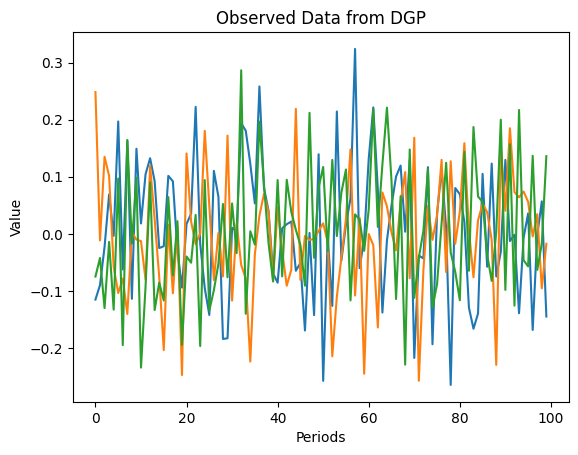

In [148]:
# simulate data from VAR process based on parameters and random coefficients
def VAR_data(V, O, T):
    A = np.random.uniform(low = -0.2, high = 0.2, size=(O, V, V)) # restricted to prevent explosive processes
    I = 0.2 * np.ones((O, V)) # initial periods of data

    observed_data = np.zeros((T+O, V))
    for t in range(0, T+O):
        if t < O:
            observed_data[t] = I[t]
        else:
            for o in range(1, O+1):
                observed_data[t] += A[o-1] @ observed_data[t-o, :] + np.random.normal(scale = 0.05, size = V) # VAR process
    observed_data = pd.DataFrame(observed_data, columns=[f'var{i}' for i in range(1, V+1)])

    observed_data = observed_data.drop(index=range(O)) # drop initial periods of data
    return observed_data.reset_index(drop = True), A

observed_data, A = VAR_data(V,O,T) # save the observed data and the matrices used to generate it (needed for true IRF)

# plot observed time series
plt.plot(observed_data)
plt.title("Observed Data from DGP")
plt.xlabel("Periods")
plt.ylabel("Value")
plt.show()

### Generating the true IRFs

In [149]:
# true IRF from for a unit var1 shock
# this is what the econometrician is trying to estimate from observed data
def true(V, O, q, A):
    shock = np.zeros(V)
    shock[0] = 1 # shock variable 1
    irf = np.zeros((q+1, V))
    for t in range(q+1):
        if t == 0:
            irf[t] = shock
        else:
            for o in range(1, O+1):
                if t-o >= 0:
                    irf[t] += A[o-1] @ irf[t-o]

    return pd.DataFrame(irf, columns=[f'var{j}_shock1' for j in range(1, V+1)])

true_irf = true(V,O,q,A)

### Estimating the IRFs using VAR

In [150]:
# VAR estimation of IRFs
model = VAR(observed_data)
var_results = model.fit(O)
irfs = var_results.irf(periods=q).irfs
var = pd.DataFrame(irfs[:,:,0])

### Estimating the IRFs using local projections

In [151]:
# estimating IRF using LPs on observed data
LP_model = SmoothLocalProjections(observed_data, "var1", None, True, O, q)
LP = pd.DataFrame(LP_model.LP().beta)

### Estimating the IRFs using smooth local projections

In [152]:
# estimating IRF using SLPs on observed data
SLP_model = SmoothLocalProjections(observed_data, "var1", None, True, O, q)
SLP = pd.DataFrame(SLP_model.SLP().beta)

### Plots

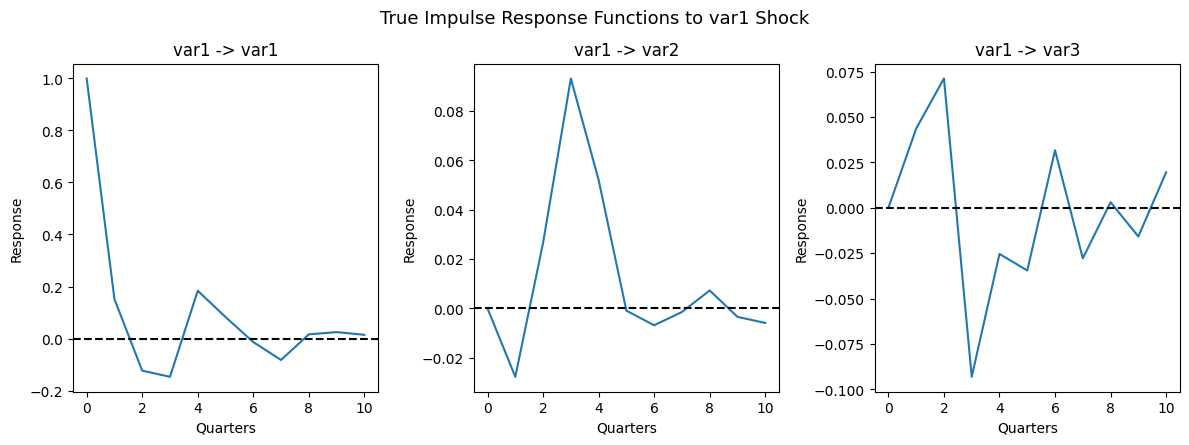

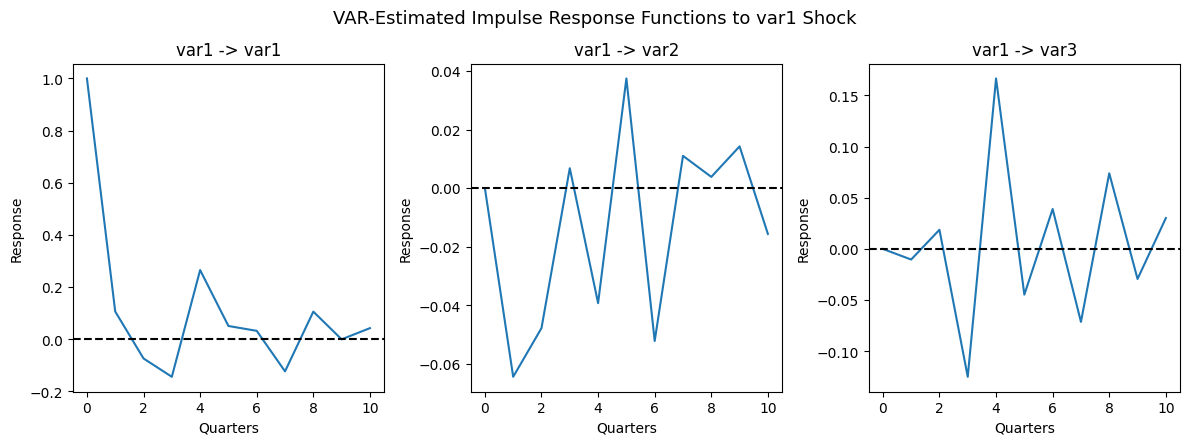

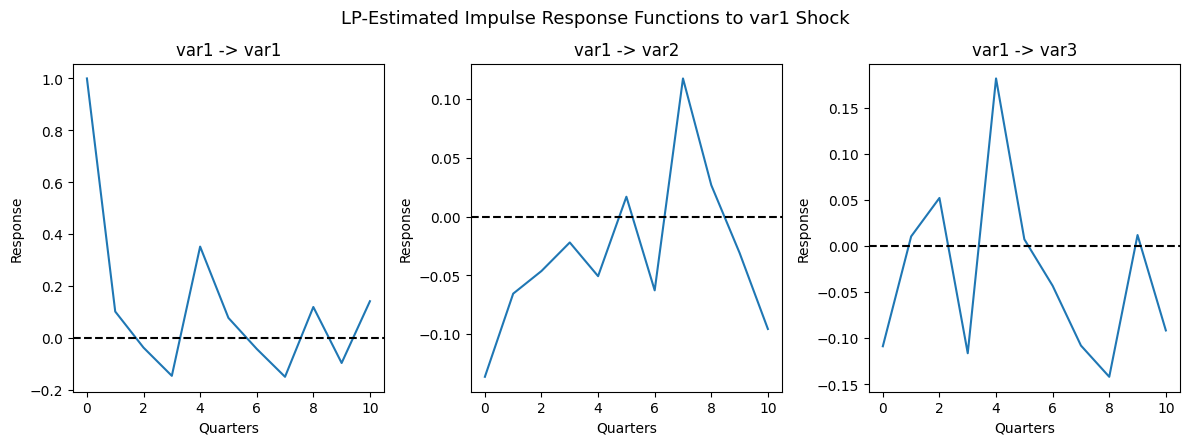

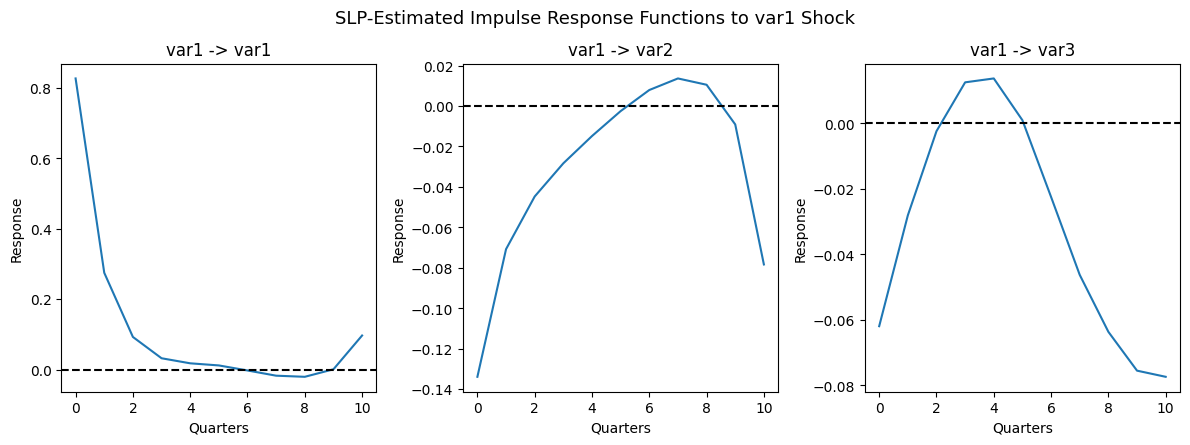

In [153]:
plot_irf(true_irf, 'True Impulse Response Functions to var1 Shock')
plot_irf(var, 'VAR-Estimated Impulse Response Functions to var1 Shock')
plot_irf(LP, 'LP-Estimated Impulse Response Functions to var1 Shock')
plot_irf(SLP, 'SLP-Estimated Impulse Response Functions to var1 Shock')

### Discussion
The accuracy of these estimation procedures can be compared by calculating the mean squared error (MSE) of each.

In [154]:
print(f"MSE of VAR IRF: {np.mean((true_irf.values - var.values)**2)}")
print(f"MSE of LP IRF: {np.mean((true_irf.values - LP.values)**2)}")
print(f"MSE of SLP IRF: {np.mean((true_irf.values - SLP.values)**2)}")

MSE of VAR IRF: 0.0031266503849930074
MSE of LP IRF: 0.008055894600573937
MSE of SLP IRF: 0.008133407120637431


In order to ensure that this result is not due to the specific pattern of shocks and coefficients drawn the procedure should be average over multiple iterations.

In [155]:
# calculating the average mean squared error (MSE) over 100 simulations
var_MSE = np.zeros(500)
LP_MSE = np.zeros(500)
SLP_MSE = np.zeros(500)

for i in range(500):
    observed_data, A = VAR_data(V,O,T)
    true_irf = true(V,O,q,A)
    
    results = model.fit(O)
    irfs = results.irf(periods=q).irfs
    var = pd.DataFrame(irfs[:,:,0])

    LP_model = SmoothLocalProjections(observed_data, "var1", None, True, O, q)
    LP = pd.DataFrame(LP_model.LP().beta)
    SLP = pd.DataFrame(LP_model.SLP().beta)

    var_MSE[i] = np.mean((true_irf.values - var.values)**2)
    LP_MSE[i] = np.mean((true_irf.values - LP.values)**2)
    SLP_MSE[i] = np.mean((true_irf.values - SLP.values)**2)

avg_var_MSE = np.mean(var_MSE)
avg_LP_MSE = np.mean(LP_MSE)
avg_SLP_MSE = np.mean(SLP_MSE)

print(f"Average MSE of VAR IRFs over 100 simulations: {avg_var_MSE:.5f}")
print(f"Average MSE of LP IRFs over 100 simulations: {avg_LP_MSE:.5f}")
print(f"Average MSE of SLP IRFs over 100 simulations: {avg_SLP_MSE:.5f}")

Average MSE of VAR IRFs over 100 simulations: 0.01216
Average MSE of LP IRFs over 100 simulations: 0.01417
Average MSE of SLP IRFs over 100 simulations: 0.01121


Also of interest is how SLP accuracy changes as a function of the smoothing parameter $\lambda$. The default value is $\lambda = 1$.

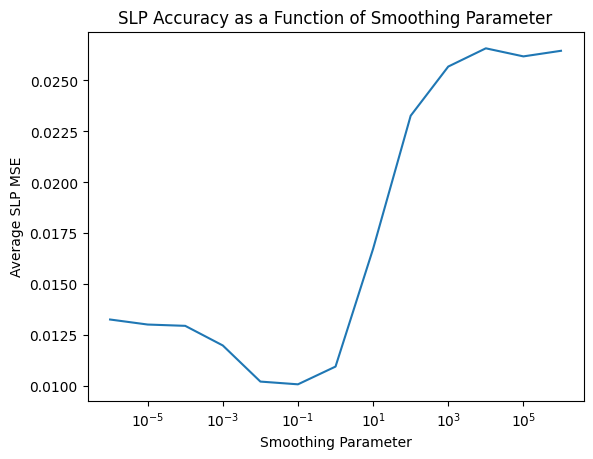

In [156]:
# evaluating how SLP MSE changes with smoothing parameter
SLP_MSE_lam = np.zeros((13,2))

for i in range(13):
    SLP_MSE = np.zeros(100)

    for j in range(100):
        observed_data, A = VAR_data(V,O,T)
        true_irf = true(V,O,q,A)

        SLP_model = SmoothLocalProjections(observed_data, "var1", None, True, O, q)
        SLP = pd.DataFrame(SLP_model.SLP(lam = 10**(i-6)).beta) # smoothing parameter values between 10^-6 and 10^6

        SLP_MSE[j] = np.mean((true_irf.values - SLP.values)**2)

    SLP_MSE_lam[i,0] = np.mean(SLP_MSE)
    SLP_MSE_lam[i,1] = 10**(i-6)

SLP_MSE_lam = pd.DataFrame(SLP_MSE_lam)

plt.plot(SLP_MSE_lam[1], SLP_MSE_lam[0])
plt.xlabel("Smoothing Parameter")
plt.ylabel("Average SLP MSE")
plt.title("SLP Accuracy as a Function of Smoothing Parameter")
plt.xscale('log')
plt.show()

The SLP MSE has a local minimum at $\lambda = 10^{-1}$ and sharply increases for higher values. Given that the underlying DGP is extremely jagged it makes sense for the optimal smoothing parameter to be low.